 # (Single) SAE Feature Analysis
 Feature heatmaps, firing rate histograms, digit distribution analysis,
 and correlation with attention difference (alpha_diff).

In [ ]:
# SETUP

import os
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, ConcatDataset

from src.utils.nb_utils import setup_notebook, load_transformer_model, load_sae
from src.data.datasets import get_dataset
from src.sae.activation_collection import collect_sae_activations, collect_attention_patterns, identify_special_features
from src.sae.metrics import compute_reconstruction_metrics, compute_sae_downstream_metrics
from src.sae.visualization import (
    create_firing_rate_histogram,
    create_feature_heatmaps,
    create_feature_heatmaps_seaborn,
    create_alpha_diff_correlation_plot,
)

DEVICE = setup_notebook(seed=42)

# Create output directory for figures (relative to repo root, not scripts dir)
REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
SAVE_DIR = os.path.join(REPO_ROOT, "results/sae_feat_analysis")
os.makedirs(SAVE_DIR, exist_ok=True)

SAE_NAME   = "../sae_checkpoints/sae_d128_k3_seed1_2layer_100dig_64d.pt" 
MODEL_NAME = "2layer_100dig_64d"
SPECIAL_THRESH = 0.3 # Threshold for identifying special features

model, model_cfg = load_transformer_model(MODEL_NAME, device=DEVICE)
D_MODEL   = model_cfg["d_model"]
LIST_LEN  = model_cfg["list_len"]
N_DIGITS  = model_cfg["n_digits"]
SEP_IDX   = model_cfg["sep_token_index"]

sae, sae_cfg = load_sae(SAE_NAME, D_MODEL, device=DEVICE)
D_SAE    = sae_cfg["dict_size"]
act_mean = sae_cfg["act_mean"].to(DEVICE)

# Full dataset (train + val) for exhaustive activation collection
train_ds, val_ds = get_dataset(n_digits=N_DIGITS, list_len=LIST_LEN, no_dupes=False, train_dupes_only=False)
all_ds  = ConcatDataset([train_ds, val_ds])
all_dl  = DataLoader(all_ds,  batch_size=256, shuffle=False)

val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

d1_all, d2_all, sae_acts_all = collect_sae_activations(
    model=model, sae=sae, val_dl=all_dl,
    act_mean=act_mean, layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
)

alpha_d1_all, alpha_d2_all = collect_attention_patterns(
    model=model, val_dl=all_dl,
    layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
)

Using device: cpu
Parsed model config (old format): 2 layers, 100 digits, 64 d_model, list_len=2
Loading model from /home2/nchw73/Year4/L4_Project/list-comp/models/2layer_100dig_64d.pt
Moving model to device:  cpu
✓ Loaded model from /home2/nchw73/Year4/L4_Project/list-comp/models/2layer_100dig_64d.pt
✓ Loaded btk SAE from ../sae_checkpoints/sae_d128_k3_seed1_2layer_100dig_64d.pt (dict_size=128)


 ## Cell 0 — SAE summary metrics

In [ ]:
firing_freq = (sae_acts_all > 0).float().mean(dim=0).numpy()
n_dead      = int((sae_acts_all.sum(dim=0) == 0).sum().item())
l0          = float((sae_acts_all > 0).float().sum(dim=1).mean())

# Explained variance
recon_metrics = compute_reconstruction_metrics(
        model=model, sae=sae, val_dl=all_dl,
        act_mean=act_mean, layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
    )

downstream = compute_sae_downstream_metrics(
    model=model, sae=sae, val_dl=all_dl,
    act_mean=act_mean, layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
)

special_info = identify_special_features(sae_acts_all, alpha_d1_all, alpha_d2_all, threshold=SPECIAL_THRESH)

print(f"SAE: {SAE_NAME}")
print(f"{'─'*60}")
print(f"  d_sae:        {D_SAE}")
print(f"  k:            {sae_cfg.get('k', '?')}")
print(f"  L0:           {l0:.2f}")
print(f"  Dead %:       {100 * n_dead / D_SAE:.1f}%  ({n_dead}/{D_SAE})")
print(f"  Exp Var:      {recon_metrics['explained_variance']:.4f}")
lr = downstream.get('loss_recovered')
print(f"  Loss Recov:   {lr:.4f}" if lr is not None else "  Loss Recov:   N/A")
print(f"  N Special:    {special_info['n_special_features']}")
print(f"{'─'*60}")

# Sort features by total activation; analyse top-N
total_act    = sae_acts_all.sum(dim=0).numpy()
top_features = np.argsort(total_act)[::-1][:20].tolist()

def compute_feature_digit_stats(feat_idx, d1_all, d2_all, sae_acts_all, n_digits):
    active_mask = sae_acts_all[:, feat_idx] > 0
    n_inputs = active_mask.sum().item()
    if n_inputs == 0:
        zeros = np.zeros(n_digits)
        return {"n_inputs": 0, "all_digit_dist": zeros, "d1_digit_dist": zeros, "d2_digit_dist": zeros}

    d1_active = d1_all[active_mask].numpy()
    d2_active = d2_all[active_mask].numpy()
    d1_counts = np.bincount(d1_active, minlength=n_digits)
    d2_counts = np.bincount(d2_active, minlength=n_digits)
    return {
        "n_inputs": n_inputs,
        "all_digit_dist": 100 * (d1_counts + d2_counts) / (2 * n_inputs),
        "d1_digit_dist":  100 * d1_counts / n_inputs,
        "d2_digit_dist":  100 * d2_counts / n_inputs,
    }

feature_stats = {
    fi: compute_feature_digit_stats(fi, d1_all, d2_all, sae_acts_all, N_DIGITS)
    for fi in tqdm(top_features, desc="Computing digit stats")
}

SAE: ../sae_checkpoints/sae_d128_k3_seed1_2layer_100dig_64d.pt
────────────────────────────────────────────────────────────
  d_sae:        128
  k:            3
  L0:           3.02
  Dead %:       3.1%  (4/128)
  Exp Var:      0.9919
  Loss Recov:   0.9991
  N Special:    2
────────────────────────────────────────────────────────────


Computing digit stats: 100%|██████████| 20/20 [00:00<00:00, 1748.25it/s]


 ## Cell 1 — Firing rate histogram (seaborn)

Firing Rate Distribution (μ=0.0236, σ=0.0559):
────────────────────────────────────────────────────────────
≥3σ from mean       : 0 features
2-3σ from mean      : 0 features
1-2σ from mean      :   2 features
  1. Feature  11: 0.6400
  2. Feature  56: 0.0991
<1σ from mean       : 126 features (not shown)


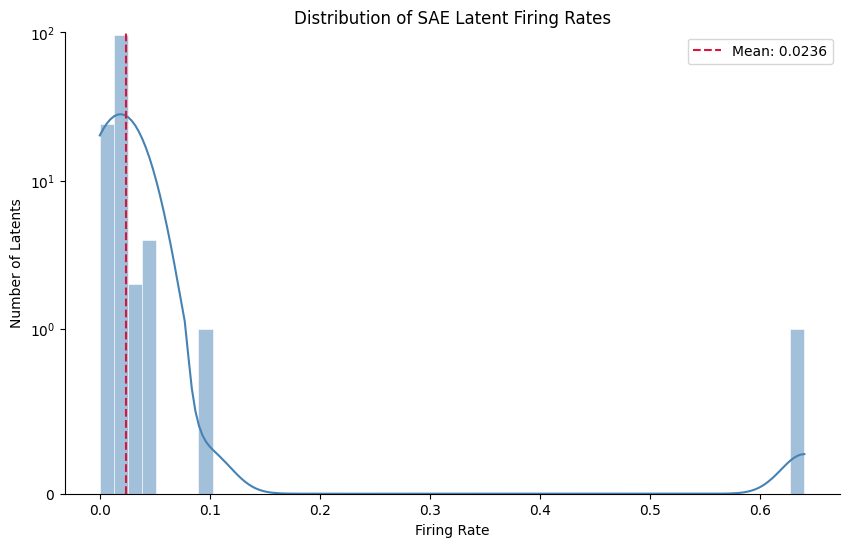


Top 3 latents by firing rate:
Latent     Fire_Rate_%     N_Active  
───────────────────────────────────
11         64.00           6400      
56         9.91            991       
2          4.12            412       


In [ ]:
fig = create_firing_rate_histogram(sae_acts_all, print_top_above_mean=True)
fig.savefig(f"{SAVE_DIR}/01_firing_rate_histogram.pdf", dpi=150, bbox_inches="tight")
plt.show()

# --- Top 3 latents by firing rate ---
top_3_indices = np.argsort(firing_freq)[-3:][::-1]
print(f"\nTop 3 latents by firing rate:")
print(f"{'Latent':<10} {'Fire_Rate_%':<15} {'N_Active':<10}")
print("─" * 35)
for idx in top_3_indices:
    fire_pct = firing_freq[idx] * 100
    n_active = (sae_acts_all[:, idx] > 0).sum().item()
    print(f"{idx:<10} {fire_pct:<15.2f} {n_active:<10}")

 ## Cell 2 — Digit distribution for top features

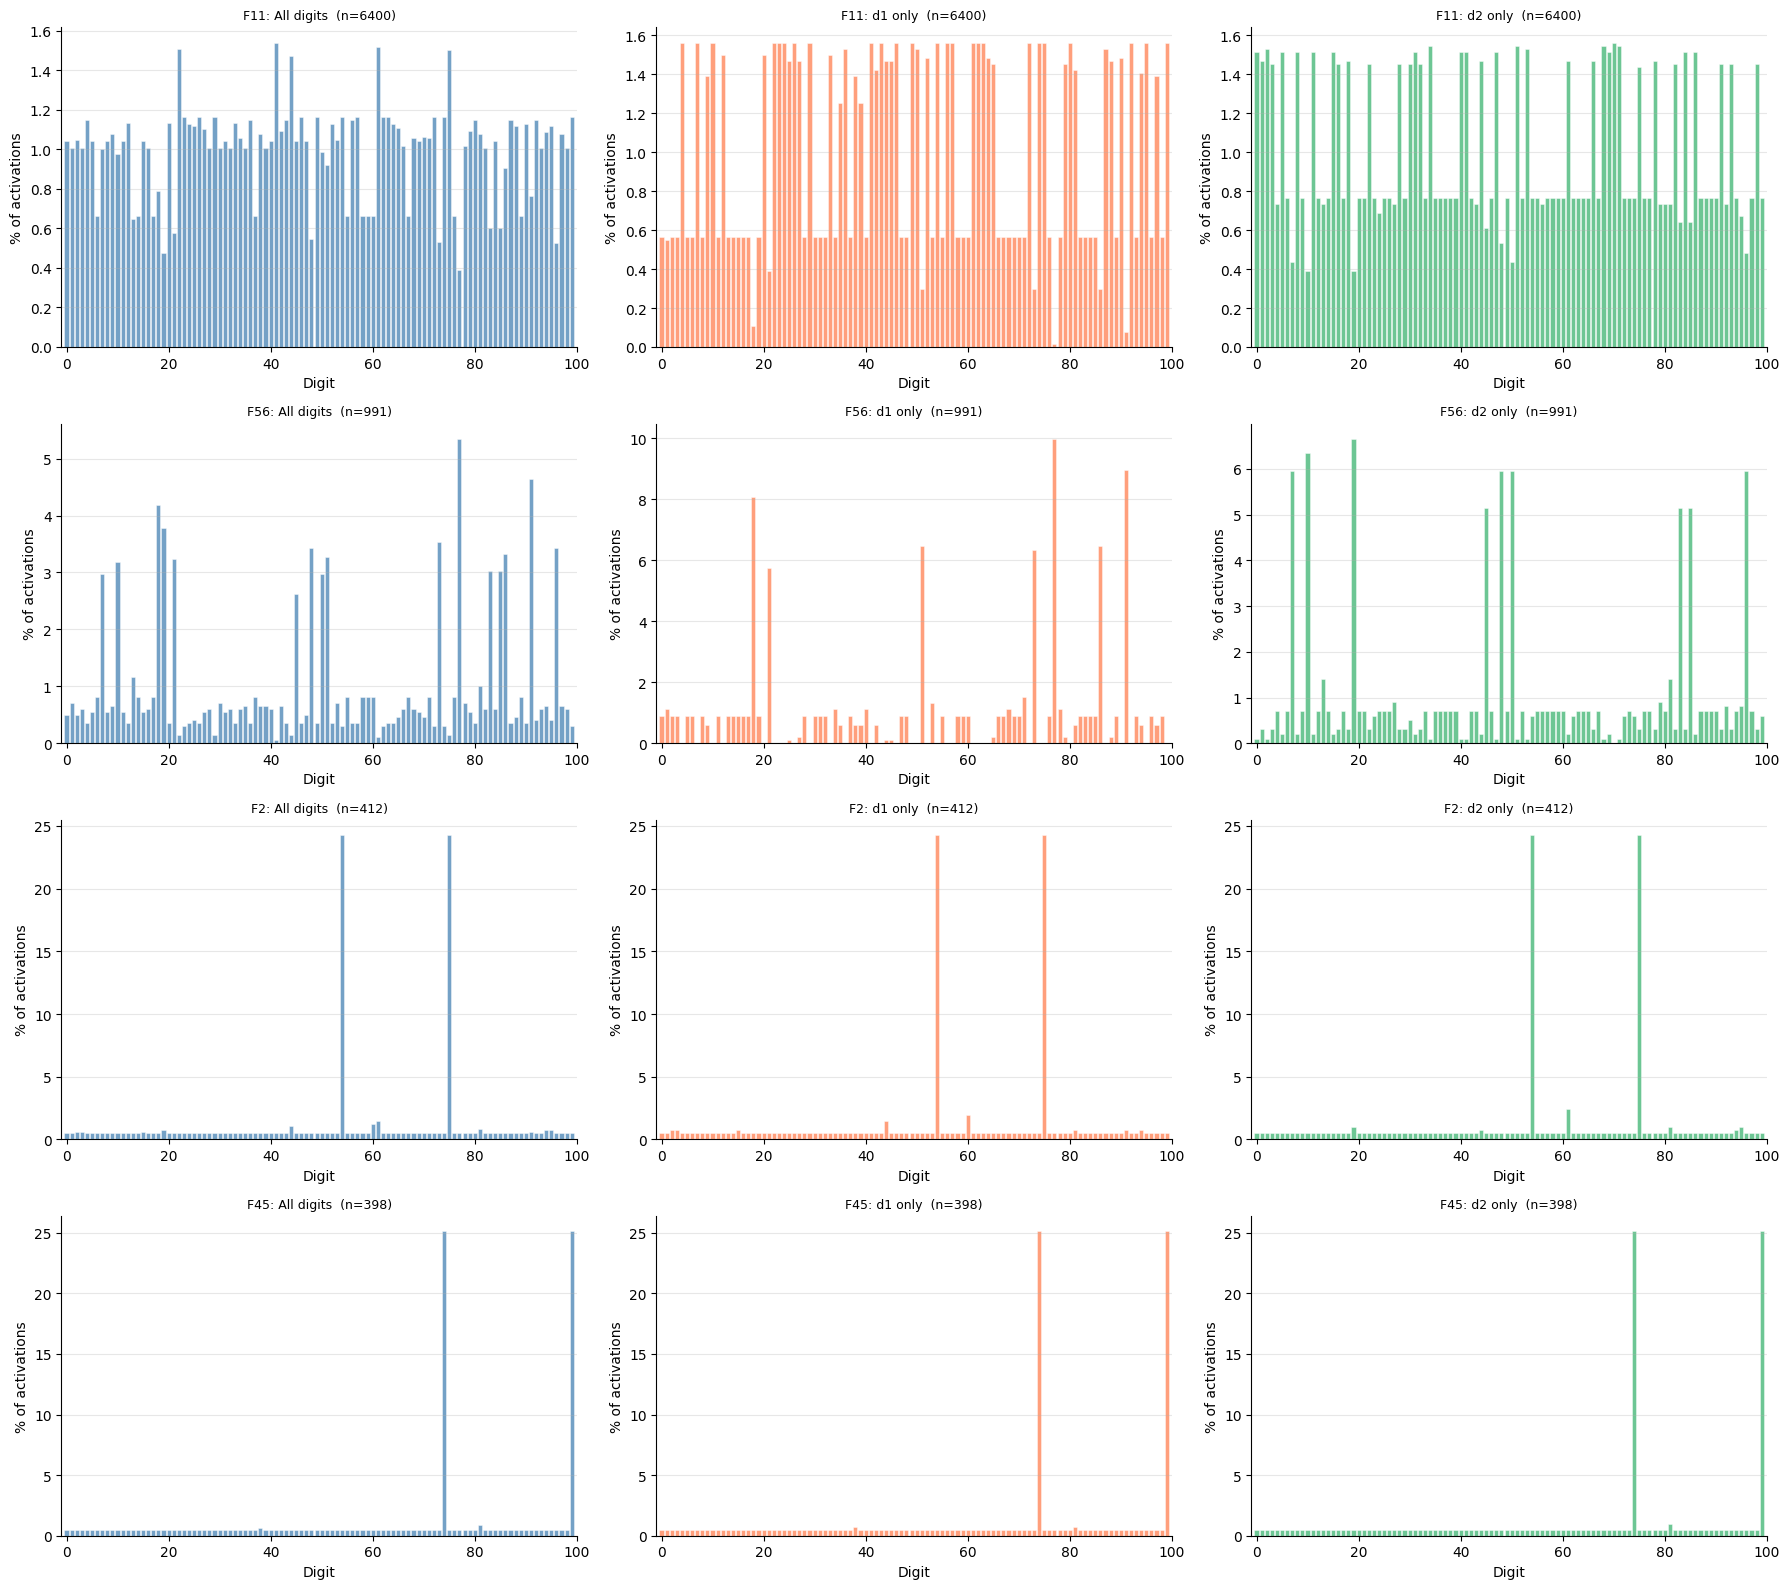

In [ ]:
# --- Visualize: grid of (all | d1 | d2) bar charts for top features ---
n_vis  = min(4, len(top_features))
digits = np.arange(N_DIGITS)

fig, axes = plt.subplots(n_vis, 3, figsize=(18, 4 * n_vis))
if n_vis == 1:
    axes = axes[np.newaxis, :]

col_colours = ["steelblue", "coral", "mediumseagreen"]
col_labels  = ["All digits", "d1 only", "d2 only"]
dist_keys   = ["all_digit_dist", "d1_digit_dist", "d2_digit_dist"]

for idx, fi in enumerate(top_features[:n_vis]):
    stats = feature_stats[fi]
    for c, (key, colour, label) in enumerate(zip(dist_keys, col_colours, col_labels)):
        ax = axes[idx, c]
        dist = stats[key]
        # Only plot non-zero values to avoid spurious bars
        nonzero_mask = dist > 0
        ax.bar(digits[nonzero_mask], dist[nonzero_mask], color=colour, alpha=0.75, edgecolor="white", linewidth=0.4)
        ax.set_xlim(-1, N_DIGITS)
        ax.set_title(f"F{fi}: {label}  (n={stats['n_inputs']})", fontsize=9)
        ax.set_xlabel("Digit")
        ax.set_ylabel("% of activations")
        ax.grid(alpha=0.3, axis="y")
        sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(f"{SAVE_DIR}/02_digit_distribution_top_features.pdf", dpi=150, bbox_inches="tight")
plt.show()

 ## Cell 3 — Full feature heatmap (Plotly interactive)

In [ ]:
fig = create_feature_heatmaps(d1_all, d2_all, sae_acts_all, 
                              n_digits=N_DIGITS, figsize=(25, 25), 
                              shared_scale=False)
fig.write_html(f"{SAVE_DIR}/03_full_feature_heatmap.html")
fig.show()

In [ ]:
# list of top 5 sae features by activation magnitude, along with some max activating examples

 ## Cell 4 — Selected feature heatmaps (seaborn, ~3 types)

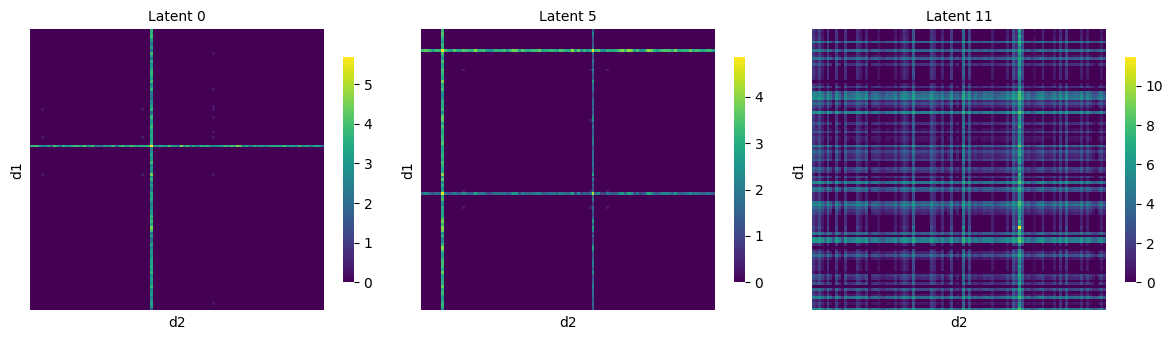

In [ ]:
# Edit this list to compare features of interest
FEATURES_TO_PLOT = [0, 5, 11] # 56
ncols = 3

fig = create_feature_heatmaps_seaborn(
    d1_all, d2_all, sae_acts_all,
    feature_indices=FEATURES_TO_PLOT,
    n_digits=N_DIGITS,
    ncols=ncols,
    shared_scale=False,
)
fig.savefig(f"{SAVE_DIR}/04_selected_features_heatmaps_unscaled.pdf", dpi=150, bbox_inches="tight")
plt.show()

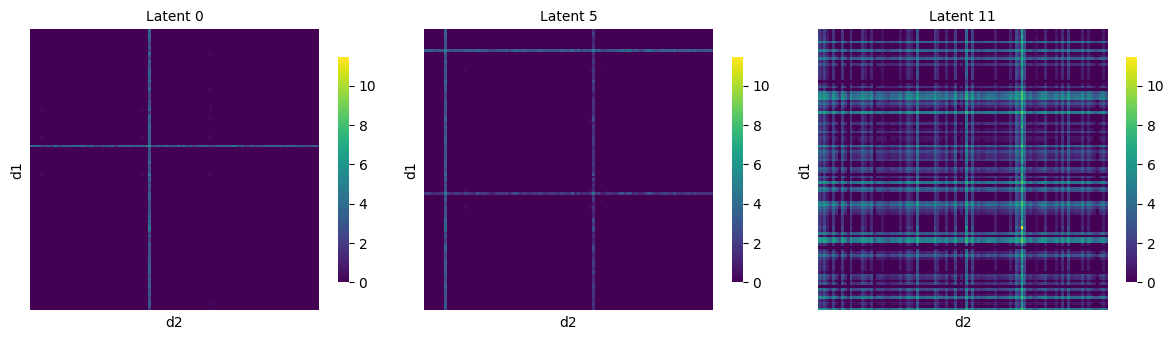

In [ ]:
# w/ shared scale
fig = create_feature_heatmaps_seaborn(
    d1_all, d2_all, sae_acts_all,
    feature_indices=FEATURES_TO_PLOT,
    n_digits=N_DIGITS,
    ncols=ncols,
    shared_scale=True,
)
fig.savefig(f"{SAVE_DIR}/05_selected_features_heatmaps_scaled.pdf", dpi=150, bbox_inches="tight")
plt.show()

 ## Cell 5 — Alpha-diff correlation analysis

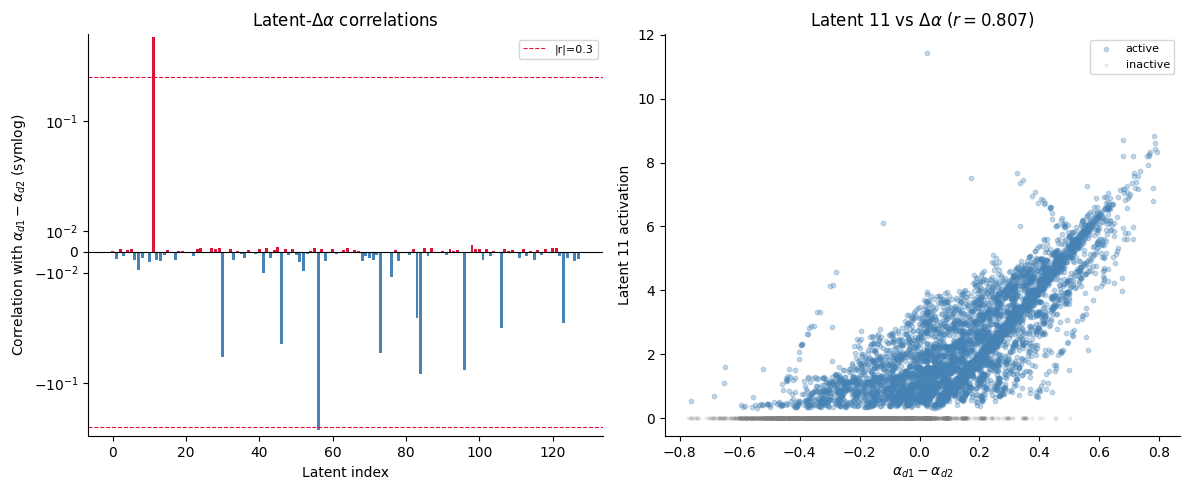


Special features (|r| > 0.3): 2
 Feature  Correlation        Type  Fire_Rate_%  N_Active
      11       0.8073 d1_favoring        64.00      6400
      56      -0.3213 d2_favoring         9.91       991

Top 3 non-special features (|r| ≤ 0.3) by correlation:
 Feature  Correlation        Type  Fire_Rate_% N_Active
      98       0.0036 d1_favoring         2.49        —
      45       0.0023 d1_favoring         3.98      398


In [ ]:
alpha_diff_correlation_plot_idx = 11
fig, correlations = create_alpha_diff_correlation_plot(
    sae_acts_all, alpha_d1_all, alpha_d2_all,
    special_thresh=SPECIAL_THRESH,
    feat_idx=alpha_diff_correlation_plot_idx,
)
fig.savefig(f"{SAVE_DIR}/06_alpha_diff_correlation_plot.pdf", dpi=150, bbox_inches="tight")
plt.show()

# --- Summary table (reuse special_info from cell 0) ---
info = special_info

rows = []
for feat_info in sorted(info["special_features"], key=lambda x: abs(x["correlation"]), reverse=True):
    fi = feat_info["feature_idx"]
    rows.append({
        "Feature": fi,
        "Correlation": round(feat_info["correlation"], 4),
        "Type": feat_info["type"],
        "Fire_Rate_%": round(float(firing_freq[fi]) * 100, 2),
        "N_Active": feature_stats[fi]["n_inputs"] if fi in feature_stats else "—",
    })

df_special = pd.DataFrame(rows)
print(f"\nSpecial features (|r| > {SPECIAL_THRESH}): {info['n_special_features']}")
print(df_special.to_string(index=False))

# --- Next 3 highest correlating features below threshold ---
print(f"\nTop 3 non-special features (|r| ≤ {SPECIAL_THRESH}) by correlation:")
rows_runner_up = []
for feat_info in info["all_correlations"].argsort()[-3:][::-1]:
    corr = float(info["all_correlations"][feat_info])
    if abs(corr) <= SPECIAL_THRESH:
        rows_runner_up.append({
            "Feature": feat_info,
            "Correlation": round(corr, 4),
            "Type": "d1_favoring" if corr > 0 else "d2_favoring",
            "Fire_Rate_%": round(float(firing_freq[feat_info]) * 100, 2),
            "N_Active": feature_stats[feat_info]["n_inputs"] if feat_info in feature_stats else "—",
        })

if rows_runner_up:
    df_runner_up = pd.DataFrame(rows_runner_up)
    print(df_runner_up.to_string(index=False))
else:
    print("(none found)")

 ## Cell 6 - Test feature steering

Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:05<00:00,  5.37s/it]


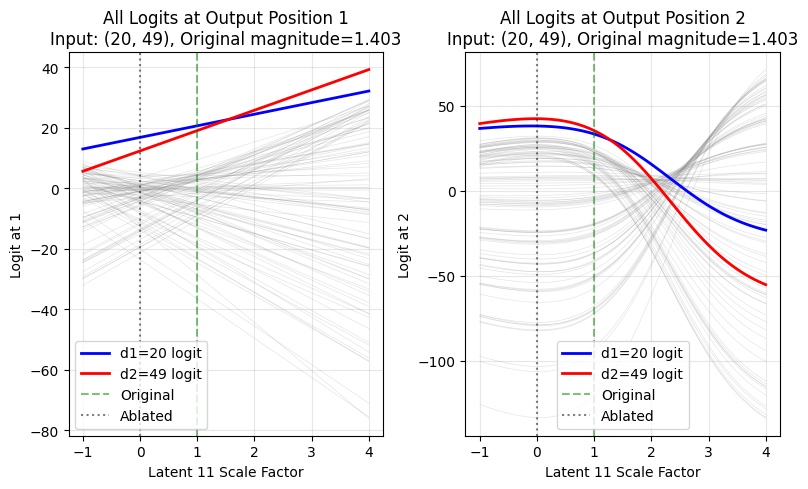


CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (20, 49)
Original feature 11 activation: 1.4032
Original model output: (20, 49)

📍 O1: Found 1 crossover point(s) (linear fit)
   Crossover at scale = 1.5463 (bound=lb)
      → Model output at nearest grid: (49, 20) SWAPPED!

📍 O2: Found 1 crossover point(s)
   Crossover #1 at scale = 1.284 (bound=lb)
      d1 logit = 30.235, d2 logit = 30.518
      → Model output: (20, 49)

--- Swap bounds ---
  Scale range: [1.5500, 2.2000]
  Midpoint: 1.8750,  Width: 0.6500


In [ ]:
from src.sae import *  # Import all SAE analysis utilities

steering_idx = 11  # Use the primary special feature identified above



results = feature_steering_experiment(
    model, sae, act_mean,
    feature_idx=steering_idx,
    d1_all=d1_all, 
    d2_all=d2_all, 
    sae_acts_all=sae_acts_all, 
    dataset=all_ds,
    test_pairs=[(20,49)],
    transpose=True,
    # save_dir=SAVE_DIR,
)

crossover_df = analyze_feature_crossovers(
    results=results,
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=steering_idx,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    layer_idx=0,
    sep_idx=2,
    verbose=True,
)

 ## Cell 7 - Co-activation analysis

In [ ]:
# check how many inputs activate latent A, how many activate latent B, and how many are activated by both and by neither (+ any other relvant stats)

# k=5
latentA = 11
latentB = 56

# k=4
# latentA = 11
# latentB = 56

# Extract activations for the two features
acts_A = sae_acts_all[:, latentA] > 0
acts_B = sae_acts_all[:, latentB] > 0

# Count activations
n_total = len(sae_acts_all)
n_A_only = (acts_A & ~acts_B).sum().item()
n_B_only = (~acts_A & acts_B).sum().item()
n_both = (acts_A & acts_B).sum().item()
n_neither = (~acts_A & ~acts_B).sum().item()

n_A = acts_A.sum().item()
n_B = acts_B.sum().item()

# Print statistics
print(f"Feature Co-activation Analysis (Latent {latentA} & {latentB})")
print(f"{'─'*60}")
print(f"  Total inputs:         {n_total}")
print(f"  Activate A only:      {n_A_only:6d}  ({100*n_A_only/n_total:5.1f}%)")
print(f"  Activate B only:      {n_B_only:6d}  ({100*n_B_only/n_total:5.1f}%)")
print(f"  Activate both A & B:  {n_both:6d}  ({100*n_both/n_total:5.1f}%)")
print(f"  Activate neither:     {n_neither:6d}  ({100*n_neither/n_total:5.1f}%)")
print(f"{'─'*60}")
print(f"  Total A activations:  {n_A:6d}  ({100*n_A/n_total:5.1f}%)")
print(f"  Total B activations:  {n_B:6d}  ({100*n_B/n_total:5.1f}%)")

# Mean activation values when active
mean_A_when_active = sae_acts_all[acts_A, latentA].mean().item() if n_A > 0 else 0
mean_B_when_active = sae_acts_all[acts_B, latentB].mean().item() if n_B > 0 else 0
print(f"  Mean A (when active): {mean_A_when_active:7.3f}")
print(f"  Mean B (when active): {mean_B_when_active:7.3f}")

# Create a co-activation contingency table
contingency = np.array([
    [n_neither, n_B_only],
    [n_A_only, n_both]
])
print(f"\nContingency Table:")
print(f"           B inactive  B active")
print(f"A inactive     {n_neither:6d}      {n_B_only:6d}")
print(f"A active       {n_A_only:6d}      {n_both:6d}")

Feature Co-activation Analysis (Latent 11 & 56)
────────────────────────────────────────────────────────────
  Total inputs:         10000
  Activate A only:        6400  ( 64.0%)
  Activate B only:         991  (  9.9%)
  Activate both A & B:       0  (  0.0%)
  Activate neither:       2609  ( 26.1%)
────────────────────────────────────────────────────────────
  Total A activations:    6400  ( 64.0%)
  Total B activations:     991  (  9.9%)
  Mean A (when active):   2.404
  Mean B (when active):   1.268

Contingency Table:
           B inactive  B active
A inactive       2609         991
A active         6400           0


 -------------
 -------------
 -------------
 -------------
 -------------
 -------------